In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from utils.preprocess import create_features
from utils.data_split import split_data
from utils.metrics import evaluate, realized_cost, expected_calibration_error, bootstrap_ci
from utils.thresholds import thr_for_precision, thr_min_cost, sweep_thresholds
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('../../../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df = create_features(df)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,_log_amount,Hour_from_start_mod24,is_night_proxy,is_business_hours_proxy
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0,1,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0,1,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0,1,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0,1,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0,1,0


In [5]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,_log_amount,Hour_from_start_mod24,is_night_proxy,is_business_hours_proxy
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,0.244200,0,5.014760,0,1,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,-0.342584,0,1.305626,0,1,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0,5.939276,0,1,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,0.139886,0,4.824306,0,1,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,-0.073813,0,4.262539,0,1,0


In [52]:
features = df.corr()['Class'].drop('Class').abs()
features = features.drop('Time').sort_values(ascending=False).index.tolist()
print(features)

['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'V1', 'V9', 'V5', 'V2', 'V6', 'V19', 'V8', 'V21', 'V27', 'V20', 'Hour_from_start_mod24', 'is_night_proxy', 'V28', '_log_amount', 'V24', 'V23', 'Amount', 'is_business_hours_proxy', 'V22', 'V26', 'V13', 'V15', 'V25']


In [53]:
X = df[features]
y = df['Class']

print(X.shape, y.shape)

(283726, 33) (283726,)


In [54]:
X_train, y_train, X_val, y_val, X_test, y_test = split_data(df, features, 'Class')

X_train: (181584, 33) y_train: (181584,)
X_val: (45396, 33) y_val: (45396,)
X_test: (56746, 33) y_test: (56746,)
Fraud rate in train: 0.001910961318177813
Fraud rate in test: 0.0013040566735981391


In [55]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

c:\BTL AI\Credit-Card-Fraud-Detection-Classification---Imbalanced-\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\BTL AI\Credit-Card-Fraud-Detection-Classification---Imbalanced-\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\BTL AI\Credit-Card-Fraud-Detection-Classification---Imbalanced-\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  Fi

In [56]:
X_train_resampled.shape, y_train_resampled.shape

((362474, 33), (362474,))

In [65]:
rf_model = RandomForestClassifier(
    n_estimators=300, 
    class_weight='balanced',
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1)


In [66]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [67]:
y_score_rf = rf_model.predict_proba(X_test)[:,1]
y_test = np.asarray(y_test)
y_score_rf = np.asarray(y_score_rf)

In [69]:
evaluate_result = []

for i in np.linspace(0.1,1,11):
    results_evaluate = evaluate(y_test, y_score_rf, i)
    evaluate_result.append(results_evaluate)

evaluate_result_df = pd.DataFrame(evaluate_result)

evaluate_result_df

,threshold,precision,recall,f1,roc_auc,auprc,brier,tp,fp,fn,tn
0,0.10,0.215278,0.837838,0.342541,0.982837,0.807052,0.000746,62,226,12,56446
1,0.19,0.610000,0.824324,0.701149,0.982837,0.807052,0.000746,61,39,13,56633
2,0.28,0.850746,0.770270,0.808511,0.982837,0.807052,0.000746,57,10,17,56662
3,0.37,0.861538,0.756757,0.805755,0.982837,0.807052,0.000746,56,9,18,56663
4,0.46,0.885246,0.729730,0.800000,0.982837,0.807052,0.000746,54,7,20,56665
5,0.55,0.962264,0.689189,0.803150,0.982837,0.807052,0.000746,51,2,23,56670
6,0.64,0.979167,0.635135,0.770492,0.982837,0.807052,0.000746,47,1,27,56671
7,0.73,1.000000,0.554054,0.713043,0.982837,0.807052,0.000746,41,0,33,56672
8,0.82,1.000000,0.472973,0.642202,0.982837,0.807052,0.000746,35,0,39,56672
9,0.91,1.000000,0.337838,0.505051,0.982837,0.807052,0.000746,25,0,49,56672


In [68]:
thr, cost = thr_min_cost(y_test, y_score_rf)

print(f"Best threshold: {thr}")
print(f"Min cost: {cost}")

Best threshold: 0.19
Min cost: 2795.0


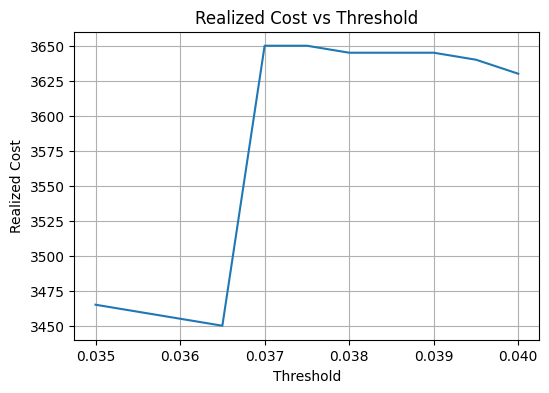

In [30]:
results_realized_cost = []

for i in np.linspace(0.035,0.04,11):
    result = [i, realized_cost(y_test, y_score_rf, i)]
    results_realized_cost.append(result)

plt.figure(figsize=(6,4))
plt.plot([r[0] for r in results_realized_cost], [r[1] for r in results_realized_cost])
plt.title('Realized Cost vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Realized Cost')
plt.grid()
plt.show()

In [31]:
thr_for_precision(y_test, y_score_rf, 0.6)

{'threshold': 0.04572094736329171,
 'precision': 0.6,
 'recall': 0.7702702702702703}

In [32]:
data_evaluate = []

for i in np.linspace(0.035,0.04,11):
    results_evaluate = evaluate(y_test, y_score_rf, i)
    results_realized_cost = realized_cost(y_test, y_score_rf, i)
    data_evaluate.append([results_evaluate['threshold'], results_evaluate['precision'], results_evaluate['recall'], results_evaluate['f1'], results_realized_cost])

results_evaluate_df = pd.DataFrame(data_evaluate, columns=['Threshold', 'Precision', 'Recall', 'F1-Score', 'Realized Cost'])

results_evaluate_df


,Threshold,Precision,Recall,F1-Score,Realized Cost
0,0.0350,0.522523,0.783784,0.627027,3465.0
1,0.0355,0.527273,0.783784,0.630435,3460.0
2,0.0360,0.532110,0.783784,0.633880,3455.0
3,0.0365,0.537037,0.783784,0.637363,3450.0
4,0.0370,0.532710,0.770270,0.629834,3650.0
5,0.0375,0.532710,0.770270,0.629834,3650.0
6,0.0380,0.537736,0.770270,0.633333,3645.0
7,0.0385,0.537736,0.770270,0.633333,3645.0
8,0.0390,0.537736,0.770270,0.633333,3645.0
9,0.0395,0.542857,0.770270,0.636872,3640.0


In [33]:
result_expected_calibration_error = expected_calibration_error(y_test, y_score_rf)

print(f"{result_expected_calibration_error*100:.4f}%")

0.0240%


In [34]:
results_booststrap_ci = bootstrap_ci(y_test, y_score_rf, roc_auc_score)
print(f"95% CI for AUC-ROC: {results_booststrap_ci[0]:.4f} - {results_booststrap_ci[1]:.4f}")

95% CI for AUC-ROC: 0.9725 - 0.9939


In [70]:
lr_model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

In [71]:
lr_model.fit(X_train, y_train)

c:\BTL AI\Credit-Card-Fraud-Detection-Classification---Imbalanced-\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [72]:
y_score_lr = lr_model.predict_proba(X_test)[:,1]
y_score_lr = np.asarray(y_score_lr)

In [73]:
thr_lr, cost_lr = thr_min_cost(y_test, y_score_lr)

print(f"Best threshold: {thr_lr}")
print(f"Min cost: {cost_lr}")

Best threshold: 0.967
Min cost: 2985.0


In [74]:
y_score_esemble = (y_score_rf + y_score_lr) / 2
thr_ensemble, cost_ensemble = thr_min_cost(y_test, y_score_esemble)

print(f"Best threshold: {thr_ensemble}")
print(f"Min cost: {cost_ensemble}")

Best threshold: 0.5690000000000001
Min cost: 2845.0


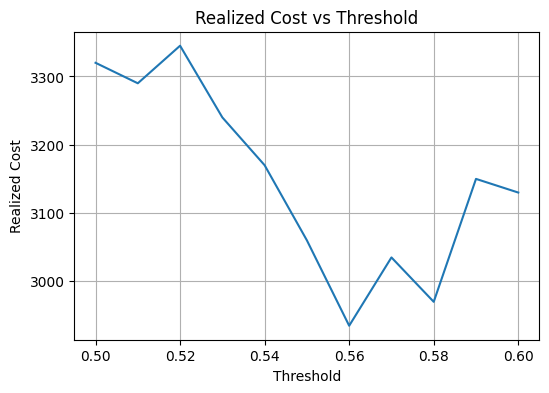

In [75]:
results_realized_cost_ensemble = []

for i in np.linspace(0.5,0.6,11):
    result = [i, realized_cost(y_test, y_score_esemble, i)]
    results_realized_cost_ensemble.append(result)

plt.figure(figsize=(6,4))
plt.plot([r[0] for r in results_realized_cost_ensemble], [r[1] for r in results_realized_cost_ensemble])
plt.title('Realized Cost vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Realized Cost')
plt.grid()
plt.show()

In [48]:
data_evaluate_ensemble = []

for i in np.linspace(0.5,0.51,51):
    results_evaluate = evaluate(y_test, y_score_esemble, i)
    results_realized_cost = realized_cost(y_test, y_score_esemble, i)
    data_evaluate_ensemble.append([results_evaluate['threshold'], results_evaluate['precision'], results_evaluate['recall'], results_evaluate['f1'], results_realized_cost])

results_evaluate_ensemble_df = pd.DataFrame(data_evaluate_ensemble, columns=['Threshold', 'Precision', 'Recall', 'F1-Score', 'Realized Cost'])

results_evaluate_ensemble_df

,Threshold,Precision,Recall,F1-Score,Realized Cost
0,0.5000,0.567308,0.797297,0.662921,3225.0
1,0.5002,0.567308,0.797297,0.662921,3225.0
2,0.5004,0.567308,0.797297,0.662921,3225.0
3,0.5006,0.572816,0.797297,0.666667,3220.0
4,0.5008,0.590000,0.797297,0.678161,3205.0
5,0.5010,0.590000,0.797297,0.678161,3205.0
6,0.5012,0.590000,0.797297,0.678161,3205.0
7,0.5014,0.590000,0.797297,0.678161,3205.0
8,0.5016,0.595960,0.797297,0.682081,3200.0
9,0.5018,0.595960,0.797297,0.682081,3200.0


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_score_esemble)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)